<a href="https://colab.research.google.com/github/zhangwiki86-soton/Data-Engineering/blob/main/Farm%20data%20normalization%20python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

In [6]:
! git clone https://github.com/zhangwiki86-soton//Data-Engineering.git

fatal: destination path 'Data-Engineering' already exists and is not an empty directory.


In [11]:
df=pd.read_csv("/content/Data-Engineering/COMM033DA_Data_Coursework (2).csv")
df

,Farm ID,Farm Location,Crop ID,Crop Name,Planting Date,Harvest Date,Soil ID,pH Level,Nitrogen Level,Phosphorus Level,...,Resource Quantity,Date of Application,Sustainability Initiative ID,Initiative Description,Date Initiated,Expected Impact,Crop Yield,Environmental Impact Score,Water Source,Labour Hours
0,1,"South Farm, Kent",101,Wheat,15/03/2023,15/08/2023,1,6.5,50,20,...,1000,10/03/2023,1,Organic Farming,01/01/2023,Increase in yield,3000,4,River,150
1,1,"South Farm, Kent",102,Barley,16/03/2023,20/08/2023,1,6.5,50,20,...,200,12/03/2023,1,Organic Farming,01/01/2023,Increase in yield,2800,4,River,120
2,2,"Green Acres, Essex",201,Corn,10/04/2023,15/09/2023,2,6.8,40,25,...,800,05/04/2023,2,Crop Rotation,15/02/2023,Improved soil quality,1500,3,Borehole,200
3,2,"Green Acres, Essex",202,Soybeans,11/04/2023,20/09/2023,2,6.8,40,25,...,150,06/04/2023,2,Crop Rotation,15/02/2023,Improved soil quality,1200,3,Borehole,180
4,3,"Sunny Fields, Hampshire",301,Potatoes,20/03/2023,15/07/2023,3,6.2,30,15,...,1200,18/03/2023,3,Water Conservation,01/03/2023,Reduced water usage,2000,5,Rainwater,160
5,3,"Sunny Fields, Hampshire",302,Carrots,21/03/2023,20/07/2023,3,6.2,30,15,...,300,19/03/2023,3,Water Conservation,01/03/2023,Reduced water usage,2200,5,Rainwater,170
6,4,"Hilltop Farm, Yorkshire",401,Apples,05/04/2023,10/09/2023,4,6.4,45,22,...,900,02/04/2023,4,Soil Health Improvement,20/01/2023,Enhanced nutrient retention,1800,2,Well,140
7,4,"Hilltop Farm, Yorkshire",402,Pears,06/04/2023,15/09/2023,4,6.4,45,22,...,250,03/04/2023,4,Soil Health Improvement,20/01/2023,Enhanced nutrient retention,1600,2,Well,130
8,5,"Riverbend Farm, Cornwall",501,Tomatoes,25/03/2023,10/08/2023,5,6.7,55,28,...,1100,22/03/2023,5,Pesticide Reduction,10/02/2023,Less chemical runoff,2500,4,River,190
9,5,"Riverbend Farm, Cornwall",502,Lettuce,26/03/2023,15/08/2023,5,6.7,55,28,...,180,24/03/2023,5,Pesticide Reduction,10/02/2023,Less chemical runoff,2400,4,River,175


In [12]:

# FARM
# -----------------------------
farms = df[
    ['Farm ID', 'Farm Location', 'Water Source']
].drop_duplicates()

# -----------------------------
# SOIL
# -----------------------------
soils = df[
    ['Soil ID',
     'pH Level',
     'Nitrogen Level',
     'Phosphorus Level',
     'Potassium Level']
].drop_duplicates()

# -----------------------------
# CROP
# -----------------------------
crops = df[
    ['Crop ID',
     'Farm ID',
     'Soil ID',
     'Crop Name',
     'Planting Date',
     'Harvest Date',
     'Crop Yield',
     'Environmental Impact Score',
     'Labour Hours']
].drop_duplicates()

# -----------------------------
# RESOURCE
# -----------------------------
resources = df[
    ['Resource ID', 'Resource Type']
].drop_duplicates()

# -----------------------------
# RESOURCE APPLICATION
# -----------------------------
resource_applications = df[
    ['Crop ID',
     'Resource ID',
     'Resource Quantity',
     'Date of Application']
].drop_duplicates()

# -----------------------------
# INITIATIVE
# -----------------------------
initiatives = df[
    ['Sustainability Initiative ID',
     'Initiative Description',
     'Date Initiated',
     'Expected Impact']
].drop_duplicates()

# -----------------------------
# FARM INITIATIVE
# -----------------------------
farm_initiatives = df[
    ['Farm ID', 'Sustainability Initiative ID']
].drop_duplicates()


In [13]:
# Display tables
print("FARMS")
display(farms)

print("SOILS")
display(soils)

print("CROPS")
display(crops)

print("RESOURCES")
display(resources)

print("RESOURCE APPLICATIONS")
display(resource_applications)

print("INITIATIVES")
display(initiatives)

print("FARM INITIATIVES")
display(farm_initiatives)


FARMS


,Farm ID,Farm Location,Water Source
0,1,"South Farm, Kent",River
2,2,"Green Acres, Essex",Borehole
4,3,"Sunny Fields, Hampshire",Rainwater
6,4,"Hilltop Farm, Yorkshire",Well
8,5,"Riverbend Farm, Cornwall",River


SOILS


,Soil ID,pH Level,Nitrogen Level,Phosphorus Level,Potassium Level
0,1,6.5,50,20,180
2,2,6.8,40,25,160
4,3,6.2,30,15,150
6,4,6.4,45,22,175
8,5,6.7,55,28,200


CROPS


...

,Crop ID,Resource ID,Resource Quantity,Date of Application
0,101,1,1000,10/03/2023
1,102,2,200,12/03/2023
2,201,1,800,05/04/2023
3,202,2,150,06/04/2023
4,301,1,1200,18/03/2023
5,302,2,300,19/03/2023
6,401,1,900,02/04/2023
7,402,2,250,03/04/2023
8,501,1,1100,22/03/2023
9,502,2,180,24/03/2023


INITIATIVES


,Sustainability Initiative ID,Initiative Description,Date Initiated,Expected Impact
0,1,Organic Farming,01/01/2023,Increase in yield
2,2,Crop Rotation,15/02/2023,Improved soil quality
4,3,Water Conservation,01/03/2023,Reduced water usage
6,4,Soil Health Improvement,20/01/2023,Enhanced nutrient retention
8,5,Pesticide Reduction,10/02/2023,Less chemical runoff


FARM INITIATIVES


,Farm ID,Sustainability Initiative ID
0,1,1
2,2,2
4,3,3
6,4,4
8,5,5


In [15]:
#save csv files to drive
farms.to_csv('/content/farms.csv', index=False)
soils.to_csv('/content/soils.csv', index=False)
crops.to_csv('/content/crops.csv', index=False)
resources.to_csv('/content/resources.csv', index=False)
resource_applications.to_csv('/content/resource_applications.csv', index=False)
initiatives.to_csv('/content/initiatives.csv', index=False)
farm_initiatives.to_csv('/content/farm_initiatives.csv', index=False)


<>:36: SyntaxWarning: invalid escape sequence '\l'
<>:45: SyntaxWarning: invalid escape sequence '\l'
<>:60: SyntaxWarning: invalid escape sequence '\l'
<>:71: SyntaxWarning: invalid escape sequence '\l'
<>:79: SyntaxWarning: invalid escape sequence '\l'
<>:89: SyntaxWarning: invalid escape sequence '\l'
<>:99: SyntaxWarning: invalid escape sequence '\l'
<>:36: SyntaxWarning: invalid escape sequence '\l'
<>:45: SyntaxWarning: invalid escape sequence '\l'
<>:60: SyntaxWarning: invalid escape sequence '\l'
<>:71: SyntaxWarning: invalid escape sequence '\l'
<>:79: SyntaxWarning: invalid escape sequence '\l'
<>:89: SyntaxWarning: invalid escape sequence '\l'
<>:99: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_2906/979191225.py:36: SyntaxWarning: invalid escape sequence '\l'
  PK FarmID\l
/tmp/ipykernel_2906/979191225.py:45: SyntaxWarning: invalid escape sequence '\l'
  PK CropID\l
/tmp/ipykernel_2906/979191225.py:60: SyntaxWarning: invalid escape sequence '\l'
  PK SoilID\l
/

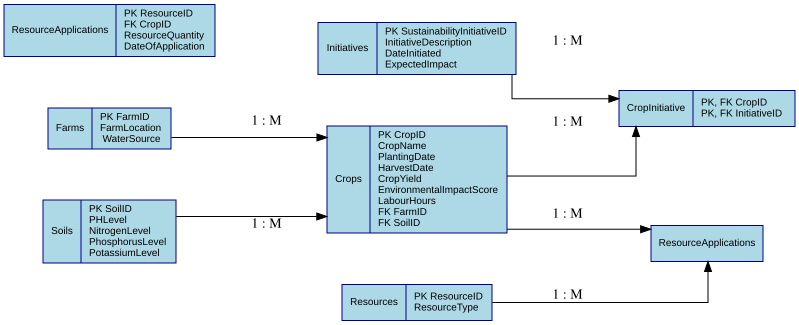

In [4]:
# Install Graphviz
!apt-get -qq install graphviz
!pip install -q graphviz

from graphviz import Digraph
from IPython.display import display

# Create ER diagram
er = Digraph("FarmDatabaseERD", format="png")

er.attr(
    rankdir="LR",
    splines="ortho",
    nodesep="0.7",
    ranksep="1.0",
    bgcolor="white"
)

er.attr(
    "node",
    shape="record",
    style="filled",
    fillcolor="lightblue",
    color="darkblue",
    fontname="Arial",
    fontsize="10"
)

# -------------------------
# Entities
# -------------------------

er.node(
    "Farms",
    """{Farms|
    PK FarmID\l
    FarmLocation\l
    WaterSource\1
    }"""
)

er.node(
    "Crops",
    """{Crops|
    PK CropID\l
    CropName\l
    PlantingDate\l
    HarvestDate\l
    CropYield\l
    EnvironmentalImpactScore\l
    LabourHours\l
    FK FarmID\l
    FK SoilID\l
    }"""
)

er.node(
    "Soils",
    """{Soils|
    PK SoilID\l
    PHLevel\l
    NitrogenLevel\l
    PhosphorusLevel\l
    PotassiumLevel\l
    }"""
)

er.node(
    "Resources",
    """{Resources|
    PK ResourceID\l
    ResourceType\l
    }"""
)

er.node(
    "Resource Applications",
    """{ResourceApplications|
    PK ResourceID\l
    FK CropID\l
    ResourceQuantity\l
    DateOfApplication\l
    }"""
)

er.node(
    "Initiatives",
    """{Initiatives|
    PK SustainabilityInitiativeID\l
    InitiativeDescription\l
    DateInitiated\l
    ExpectedImpact\l
    }"""
)

er.node(
    "CropInitiative",
    """{CropInitiative|
    PK, FK CropID\l
    PK, FK InitiativeID\l
    }"""
)

# -------------------------
# Relationships
# -------------------------

er.edge(
    "Farms",
    "Crops",
    label="1 : M"
)

er.edge(
    "Soils",
    "Crops",
    label="1 : M"
)

er.edge(
    "Crops",
    "ResourceApplications",
    label="1 : M"
)

er.edge(
    "Resources",
    "ResourceApplications",
    label="1 : M"
)

er.edge(
    "Crops",
    "CropInitiative",
    label="1 : M"
)

er.edge(
    "Initiatives",
    "CropInitiative",
    label="1 : M"
)

# Render and display
er.render("farm_database_erd", cleanup=True)

display(er)

In [17]:
import sqlite3

# Create an in-memory database
conn = sqlite3.connect(":memory:")
cursor = conn.cursor()

cursor.executescript("""
PRAGMA foreign_keys = ON;

CREATE TABLE Farm (
    FarmID INTEGER PRIMARY KEY,
    FarmLocation TEXT NOT NULL
);

CREATE TABLE Soil (
    SoilID INTEGER PRIMARY KEY,
    PHLevel REAL,
    NitrogenLevel REAL,
    PhosphorusLevel REAL,
    PotassiumLevel REAL
);

CREATE TABLE Crop (
    CropID INTEGER PRIMARY KEY,
    CropName TEXT NOT NULL,
    PlantingDate DATE,
    HarvestDate DATE,
    CropYield REAL,
    EnvironmentalImpactScore INTEGER,
    LabourHours REAL,
    FarmID INTEGER NOT NULL,
    SoilID INTEGER NOT NULL,

    FOREIGN KEY (FarmID)
        REFERENCES Farm(FarmID),

    FOREIGN KEY (SoilID)
        REFERENCES Soil(SoilID)
);

CREATE TABLE Resource (
    ResourceID INTEGER PRIMARY KEY,
    ResourceType TEXT NOT NULL
);

CREATE TABLE ResourceApplication (
    ResourceApplicationID INTEGER PRIMARY KEY AUTOINCREMENT,
    CropID INTEGER NOT NULL,
    ResourceID INTEGER NOT NULL,
    ResourceQuantity REAL,
    DateOfApplication DATE,

    FOREIGN KEY (CropID)
        REFERENCES Crop(CropID),

    FOREIGN KEY (ResourceID)
        REFERENCES Resource(ResourceID)
);

CREATE TABLE SustainabilityInitiative (
    InitiativeID INTEGER PRIMARY KEY,
    InitiativeDescription TEXT,
    DateInitiated DATE,
    ExpectedImpact TEXT
);

CREATE TABLE CropInitiative (
    CropID INTEGER NOT NULL,
    InitiativeID INTEGER NOT NULL,

    PRIMARY KEY (CropID, InitiativeID),

    FOREIGN KEY (CropID)
        REFERENCES Crop(CropID),

    FOREIGN KEY (InitiativeID)
        REFERENCES SustainabilityInitiative(InitiativeID)
);
""")

print("Database created successfully.")


Database created successfully.
